# KKBox Churn — False Positive / False Negative Analysis (ticket A-06)

A focused error analysis on the existing temporal-holdout predictions from `06_risk_scoring.ipynb`
-- **no retraining, no re-scoring, no change to the production scoring pipeline**. This notebook
only reads `outputs/kkbox_modeling_dataset_v2.csv` (features) and
`outputs/risk_scoring_predictions.csv` (`risk_score_full`, already computed) and cross-tabulates
them.

## Operational threshold used

**0.65** -- the same Medium-tier cutoff documented in `11_threshold_rationale.ipynb` (ticket A-05).
This is the dashboard's actual "does this customer get any retention treatment at all" boundary:
every segment in `outputs/marketing_action_plan.csv` is built from `risk_tier in {High, Medium}`
(score &ge; 0.65), while Low tier is uniformly "no action -- monitor only". Framing false
positives/negatives around this cutoff answers the operationally relevant question -- "who do we
contact that we shouldn't, and who do we miss" -- rather than an arbitrary 0.5.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 100

OUT_DIR = Path("..") / "outputs"
THRESHOLD = 0.65

features = pd.read_csv(OUT_DIR / "kkbox_modeling_dataset_v2.csv")
scores = pd.read_csv(OUT_DIR / "risk_scoring_predictions.csv", usecols=["msno", "risk_score_full"])
df = features.merge(scores, on="msno", how="left")
assert df["risk_score_full"].isna().sum() == 0

df["predicted_positive"] = df["risk_score_full"] >= THRESHOLD

def confusion_group(row):
    if row["predicted_positive"] and row["is_churn"] == 1:
        return "TP"
    if row["predicted_positive"] and row["is_churn"] == 0:
        return "FP"
    if not row["predicted_positive"] and row["is_churn"] == 1:
        return "FN"
    return "TN"

df["confusion_group"] = df.apply(confusion_group, axis=1)
print(f"{len(df):,} customers, threshold={THRESHOLD}")
df["confusion_group"].value_counts()

970,960 customers, threshold=0.65


confusion_group
TN    811202
FP     72428
TP     57307
FN     30023
Name: count, dtype: int64

## 1. Confusion matrix at threshold 0.65

Cross-checked against the already-saved `risk_scoring_threshold_analysis.csv` row for this exact
threshold -- precision/recall computed here must match what notebook 06 already reported, or
something is wrong with this notebook's re-derivation.

In [2]:
cm = pd.crosstab(df["is_churn"].map({0: "Actual: No churn", 1: "Actual: Churn"}),
                  df["predicted_positive"].map({False: "Predicted: Low (no flag)", True: "Predicted: Medium/High (flagged)"}))
cm = cm.reindex(index=["Actual: No churn", "Actual: Churn"],
                 columns=["Predicted: Low (no flag)", "Predicted: Medium/High (flagged)"])
cm

predicted_positive,Predicted: Low (no flag),Predicted: Medium/High (flagged)
is_churn,,
Actual: No churn,811202,72428
Actual: Churn,30023,57307


In [3]:
tp = (df["confusion_group"] == "TP").sum()
fp = (df["confusion_group"] == "FP").sum()
fn = (df["confusion_group"] == "FN").sum()
tn = (df["confusion_group"] == "TN").sum()

precision = tp / (tp + fp)
recall = tp / (tp + fn)

sweep = pd.read_csv(OUT_DIR / "risk_scoring_threshold_analysis.csv")
saved_row = sweep.loc[sweep["threshold"].round(2) == THRESHOLD].iloc[0]

print(f"TP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,}")
print(f"Precision (re-derived):  {precision:.6f}   (saved: {saved_row['precision']:.6f})")
print(f"Recall (re-derived):     {recall:.6f}   (saved: {saved_row['recall']:.6f})")
assert abs(precision - saved_row["precision"]) < 1e-6
assert abs(recall - saved_row["recall"]) < 1e-6
print("\nMatches notebook 06's saved sweep exactly.")

TP=57,307  FP=72,428  FN=30,023  TN=811,202
Precision (re-derived):  0.441724   (saved: 0.441724)
Recall (re-derived):     0.656212   (saved: 0.656212)

Matches notebook 06's saved sweep exactly.


## 2. FP vs. FN behavioral profiles

Comparing the two error groups against each other and against the two correct groups (TP, TN) on
every feature the ticket names: auto-renew status, recency, tenure, transaction volume/value,
payment method, membership status.

In [4]:
numeric_features = [
    "latest_is_auto_renew", "auto_renew_pct", "days_since_last_txn", "tenure_days_at_cutoff",
    "total_transactions", "avg_revenue_per_txn", "total_revenue", "latest_is_cancel",
    "membership_remaining_days", "cancel_rate",
]
profile = df.groupby("confusion_group")[numeric_features].median().reindex(["TP", "FP", "FN", "TN"])
profile.index.name = "Group (median values)"
profile

,latest_is_auto_renew,auto_renew_pct,days_since_last_txn,tenure_days_at_cutoff,total_transactions,avg_revenue_per_txn,total_revenue,latest_is_cancel,membership_remaining_days,cancel_rate
Group (median values),,,,,,,,,,
TP,0.0,0.0,26.0,876.0,5.0,165.000000,1782.0,0.0,13.0,0.0
FP,0.0,0.0,16.0,776.0,9.0,149.000000,1650.0,0.0,15.0,0.0
FN,1.0,1.0,20.0,1303.0,18.0,147.888889,2682.0,0.0,14.0,0.0
TN,1.0,1.0,13.0,1036.0,17.0,133.634146,1937.0,0.0,17.0,0.0


In [5]:
top_payment = (
    df.groupby("confusion_group")["latest_payment_method_id"]
    .apply(lambda s: s.value_counts(normalize=True).head(1))
    .rename("share_of_group")
    .reset_index()
    .rename(columns={"level_1": "most_common_payment_method_id"})
)
top_payment = top_payment.set_index("confusion_group").reindex(["TP", "FP", "FN", "TN"])
top_payment["share_of_group"] = (top_payment["share_of_group"] * 100).round(1)
print("Single most common payment method within each group, and what share of that group uses it:")
top_payment

Single most common payment method within each group, and what share of that group uses it:


,most_common_payment_method_id,share_of_group
confusion_group,,
TP,38.0,40.4
FP,38.0,53.4
FN,41.0,54.7
TN,41.0,64.4


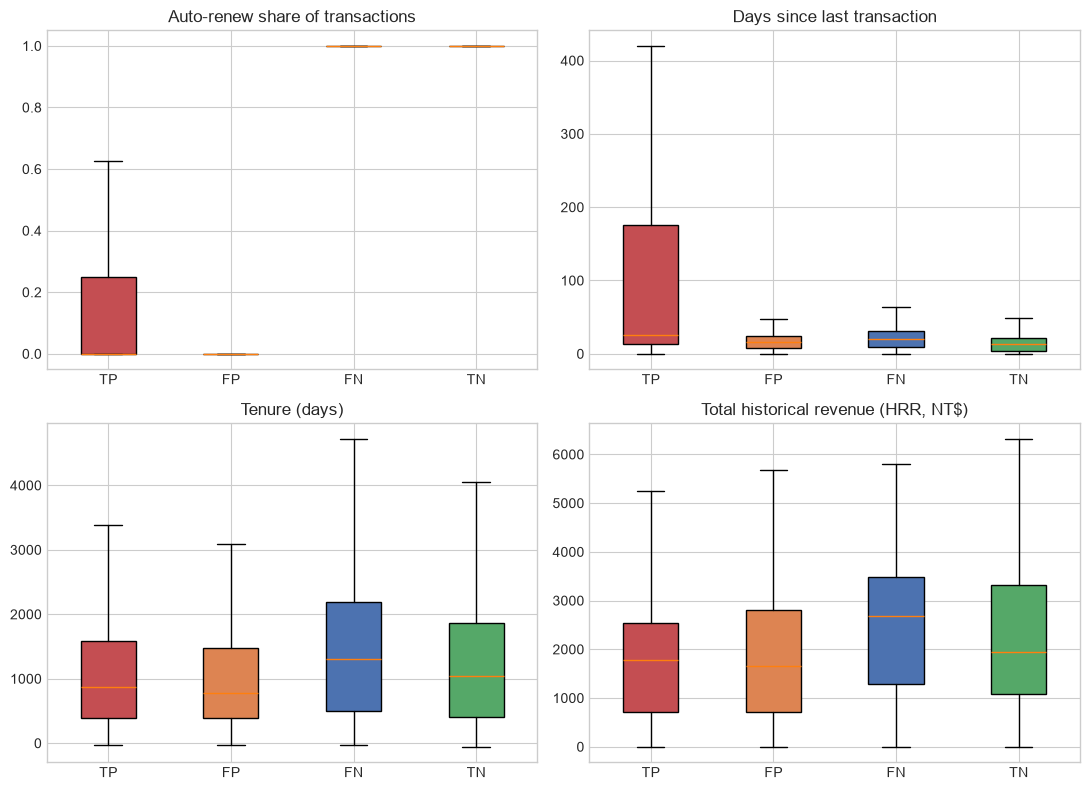

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
plot_specs = [
    ("auto_renew_pct", "Auto-renew share of transactions", axes[0, 0]),
    ("days_since_last_txn", "Days since last transaction", axes[0, 1]),
    ("tenure_days_at_cutoff", "Tenure (days)", axes[1, 0]),
    ("total_revenue", "Total historical revenue (HRR, NT$)", axes[1, 1]),
]
colors = {"TP": "#C44E52", "FP": "#DD8452", "FN": "#4C72B0", "TN": "#55A868"}
for col, title, ax in plot_specs:
    data = [df.loc[df["confusion_group"] == g, col].dropna() for g in ["TP", "FP", "FN", "TN"]]
    bp = ax.boxplot(data, tick_labels=["TP", "FP", "FN", "TN"], patch_artist=True, showfliers=False)
    for patch, g in zip(bp["boxes"], ["TP", "FP", "FN", "TN"]):
        patch.set_facecolor(colors[g])
    ax.set_title(title)
plt.tight_layout()
plt.show()

## 3. Findings

**Numbers below are this run's actual printed output (§2), not a generic template.**

- **The model's biggest blind spot is long-tenured, high-value customers, not marginal ones.**
  FN (missed churners) have the *highest* median tenure of all four groups (1,303 days) and the
  *highest* median historical revenue (NT$2,682) -- above even TP (876 days, NT$1,782) and TN
  (1,036 days, NT$1,937). The customers this model fails to flag are disproportionately veteran,
  higher-spending accounts, not edge cases -- operationally the costliest kind of miss, since
  these are exactly the accounts a retention team would most want advance warning on.
- **Auto-renew status and payment method cleanly separate the two error types along the model's
  own strongest signal.** Median `latest_is_auto_renew` is 0 (off) for both TP and FP, and 1 (on)
  for both FN and TN; the single most common payment method matches the same split (code 38 for
  TP/FP, code 41 for FN/TN). This is reassuring, not concerning: the model is using its top driver
  (per the SHAP ranking on Risk Intelligence) exactly as intended -- FP customers look risky on the
  same axis genuine churners do, they simply didn't churn *this specific month*.
- **Recency does not split as cleanly.** TP has the *longest* gap since last transaction of any
  group (26 days) -- longer than FN (20), FP (16), or TN (13). FP customers, despite auto-renew
  being off, were still transacting comparatively recently (16 days, close to TN's 13) -- so
  recency alone doesn't separate "flagged and right" from "flagged and wrong"; it's the
  *combination* of signals that matters, not any single one.
- **Transaction volume tracks tenure, not error type**: FN and TN both show far more historical
  transactions (medians 18 and 17) than TP and FP (5 and 9) -- unsurprising given FN's longer
  tenure, but it means transaction *count* alone would be a poor error-type discriminator.
  Per-transaction spend is closer between the two error groups (FN 147.9, FP 149.0 NT$/txn), both
  between TN (133.6) and TP (165.0).
- **`latest_is_cancel` and `cancel_rate` show no signal at the median** (0 for all four groups) --
  expected, since cancellation is rare overall (~1.4% base rate) and a median is the wrong
  statistic for a mostly-zero flag. A rate/mean comparison would be needed to check this feature
  properly; noted here as a limitation of this pass rather than a finding.
- **Practical implication for a retention team**: the highest-value fix available isn't "flag more
  people" (that trades away precision, per `11_threshold_rationale.ipynb`'s sensitivity analysis)
  -- it's recognizing that long-tenured, high-revenue customers are systematically under-flagged,
  and may warrant a monitoring rule independent of the model score (e.g. a manual review trigger
  for high-HRR accounts regardless of tier). FP customers, sharing TP's auto-renew/payment-method
  profile, remain defensible retention targets even when they don't churn this particular month.
- **No causal claim is made anywhere above.** These are observed associations between confusion-
  group membership and existing behavioral features in one temporal holdout -- not evidence that
  any feature *causes* the model to err, and not a claim that contacting FP or FN customers would
  change their outcome.

**This analysis does not change the production scoring pipeline, the risk thresholds, or any
existing output.** New artifact saved: `outputs/error_analysis_summary.json` (confusion matrix +
group medians from this run, for reuse without re-running this notebook).

In [7]:
summary = {
    "threshold_used": THRESHOLD,
    "threshold_rationale": "Same Medium-tier cutoff as 11_threshold_rationale.ipynb (A-05) -- the dashboard's actual intervention boundary.",
    "confusion_matrix": {"TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn)},
    "precision": float(precision),
    "recall": float(recall),
    "group_medians": profile.round(4).to_dict(orient="index"),
    "note": "Associations only -- no causal claims. See notebook 12_error_analysis.ipynb for full findings.",
}
with open(OUT_DIR / "error_analysis_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=float)
print("Saved:", OUT_DIR / "error_analysis_summary.json")

Saved: ..\outputs\error_analysis_summary.json
